# Useful Documentation Links

- pandas: https://pandas.pydata.org/docs/reference/index.html
- scikitlearn: https://scikit-learn.org/stable/api/index.html
- feature engine: https://feature-engine.trainindata.com/en/latest/api_doc/index.html
- mlxtend: https://rasbt.github.io/mlxtend/api_subpackages/mlxtend.feature_selection/
- scipy: https://docs.scipy.org/doc/scipy/

In [24]:
!pip install feature_engine
!pip install mlxtend
!pip install scikit-learn==1.4

In [25]:
import pandas as pd, numpy as np, seaborn as sns
import sklearn, scipy, torch
import matplotlib.pyplot as plt
import plotly.express as px
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler

from sklearn.decomposition import TruncatedSVD, PCA

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.model_selection import cross_val_predict, cross_validate, cross_val_score
from sklearn.model_selection import train_test_split, StratifiedKFold

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Work 2024-2025/DataPreparation')
import adsa_utils as ad

In [26]:
charity = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Work 2024-2025/DataPreparation/charityNumeric.csv', sep=';')
charity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2398 entries, 0 to 2397
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pre-campaign expenditure  2398 non-null   float64
 1   Pre-campaign visits       2398 non-null   float64
 2   Total number of visits    2398 non-null   float64
 3   Total spend               2398 non-null   float64
 4   52 Mosaic Groups          2398 non-null   float64
 5   Mosaic Bands              2398 non-null   float64
 6   Year Of Birth             2398 non-null   float64
 7   Age                       2398 non-null   float64
 8   Response to campaign      2398 non-null   object 
dtypes: float64(8), object(1)
memory usage: 168.7+ KB


In [27]:
charity.describe()

,Pre-campaign expenditure,Pre-campaign visits,Total number of visits,Total spend,52 Mosaic Groups,Mosaic Bands,Year Of Birth,Age
count,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000
mean,89.352794,4.378649,5.221435,104.657214,18.804837,4.601334,1950.366555,43.633445
std,95.663303,6.201329,7.542659,122.778809,14.337616,3.100384,13.444036,13.444036
min,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1902.000000,19.000000
25%,59.000000,1.000000,2.000000,61.000000,7.000000,2.000000,1942.000000,33.000000
50%,72.000000,3.000000,3.000000,78.000000,12.000000,3.000000,1952.000000,42.000000
75%,88.000000,5.000000,6.000000,98.000000,31.000000,7.000000,1961.000000,52.000000
max,1303.000000,116.000000,131.000000,1787.000000,51.000000,12.000000,1975.000000,92.000000


In [28]:
charity[charity.columns.difference(['Response to campaign'])].corr()

,52 Mosaic Groups,Age,Mosaic Bands,Pre-campaign expenditure,Pre-campaign visits,Total number of visits,Total spend,Year Of Birth
52 Mosaic Groups,1.000000,-0.110326,0.993963,-0.009259,0.004693,0.011059,0.006220,0.110326
Age,-0.110326,1.000000,-0.106709,0.035100,0.082770,0.093813,0.056893,-1.000000
Mosaic Bands,0.993963,-0.106709,1.000000,-0.007386,0.006900,0.014659,0.010261,0.106709
Pre-campaign expenditure,-0.009259,0.035100,-0.007386,1.000000,0.829242,0.817275,0.930795,-0.035100
Pre-campaign visits,0.004693,0.082770,0.006900,0.829242,1.000000,0.976092,0.797224,-0.082770
Total number of visits,0.011059,0.093813,0.014659,0.817275,0.976092,1.000000,0.841645,-0.093813
Total spend,0.006220,0.056893,0.010261,0.930795,0.797224,0.841645,1.000000,-0.056893
Year Of Birth,0.110326,-1.000000,0.106709,-0.035100,-0.082770,-0.093813,-0.056893,1.000000


In [29]:
# separate reg. attr. from class label attr.
X = charity[charity.columns.difference(['Response to campaign'])]
y = charity['Response to campaign']
# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

## Baseline

In [30]:
clf = SVC(random_state=43)
# crossvalidate on the train portion using the custom function
ad.cross_validation_avg_scores(X_train, y_train, clf)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

Mean Accuracy is 73.77 +/- 1.04
Mean Precision is 81.13 +/- 3.31
Mean Recall is 58.22 +/- 1.39
Mean F-score is 56.46 +/- 2.11
               precision    recall  f1-score   support

Non-responder       0.72      0.99      0.83       323
    Responder       0.92      0.21      0.34       157

     accuracy                           0.74       480
    macro avg       0.82      0.60      0.59       480
 weighted avg       0.78      0.74      0.67       480



## SVD
- there are several libraries that implement SVD, including:
1. numpy, scipy and torch offer similar implementations in linalg package
  - note: torch has a function that allows us to get the singular values
2. sklearn has an implementation called TruncatedSVD which considers only the most significant singular values:
  - we need to specify the number of components
  - the components are accessed via the 'singular_values_' attribute
  - we can also retrieve the proportion of explained variance of each component using the 'explained_variance_ratio_' attribute
  - the attributes' loadings onto components are given by the transposed of the components and singular values.
3. mlxtend has an implementation called PCA via SVD: it has useful attributes to access the components and the loadings.
- NOTE: we will be using mainly the sklearn because they all give similar results

In [31]:
# sklearn truncated svd with all components
svd = TruncatedSVD(n_components=len(X.columns), random_state=43)
svd.fit(X)
s = svd.singular_values_
print([format("%.3f" % singular_value) for singular_value in s])
# also print the proportions of explained variance
print([format("%.3f" % expl_var) for expl_var in svd.explained_variance_ratio_])

['95778.233', '7490.127', '1374.467', '735.562', '649.938', '254.329', '36.485', '16.239']
['0.011', '0.940', '0.032', '0.009', '0.007', '0.001', '0.000', '0.000']


In [32]:
# looking at the result above, we can easily use only 5 out of the 8 components
svd = TruncatedSVD(n_components=5, algorithm='arpack', random_state=43)
X_svd = svd.fit_transform(X_train)
# store the components into a dataframe
X_svd = pd.DataFrame(X_svd, columns=list(svd.get_feature_names_out()))
X_svd.head()

,truncatedsvd0,truncatedsvd1,truncatedsvd2,truncatedsvd3,truncatedsvd4
0,1939.891446,3.721381,-3.727072,-18.304400,9.149845
1,1933.881048,-58.462116,-2.217797,7.799178,27.057005
2,1972.829936,-19.218352,-8.503842,19.085294,-10.337647
3,1948.599282,-27.136371,-6.830773,-5.612530,3.547278
4,1936.254763,-6.157846,-6.747698,-20.758818,11.602002


In [33]:
# svd loadings are computed as: svd.components_.T X svd.singular_values_
svd_loadings = svd.components_.T * svd.singular_values_
# put them into a dataframe: the rows are the original attributes and columns are the new components
svd_loadings = pd.DataFrame(svd_loadings, index=X.columns,
                  columns=[f'SVD{i}' for i in range(len(svd.components_))])
svd_loadings

,SVD0,SVD1,SVD2,SVD3,SVD4
52 Mosaic Groups,833.928551,-10.113166,18.108801,557.154601,294.387894
Age,1904.451229,25.974740,38.175043,-340.062864,504.221928
Mosaic Bands,203.890324,-1.759994,5.078760,119.287985,63.864396
Pre-campaign expenditure,3920.911178,4142.236938,-872.956490,-0.032330,15.179564
Pre-campaign visits,193.654691,226.214696,-25.743718,-2.176413,14.076542
Total number of visits,229.687502,278.367898,13.916604,-3.612047,16.923468
Total spend,4548.251434,5247.019133,689.580595,3.261004,-16.666737
Year Of Birth,85419.557008,-471.256549,2.333756,1.700200,-14.154981


<Axes: >

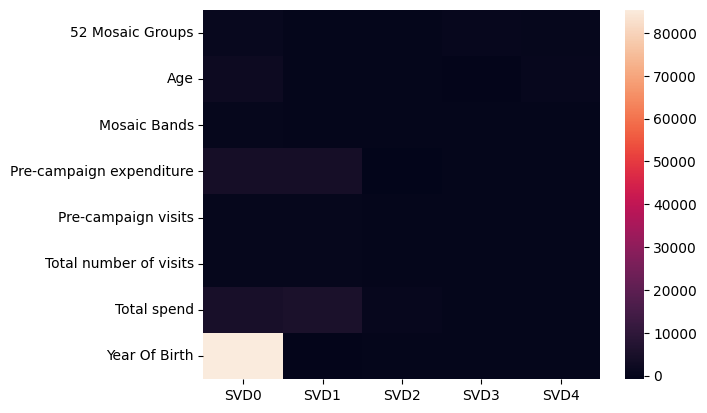

In [34]:
sns.heatmap(svd_loadings)

In [35]:
# use this new dimensions to train model
X_test_svd = svd.transform(X_test)
X_test_svd = pd.DataFrame(X_test_svd, columns=list(svd.get_feature_names_out()))
clf = SVC(random_state=43)
ad.cross_validation_avg_scores(X_svd, y_train, clf)
y_pred = clf.predict(X_test_svd)
print(classification_report(y_test, y_pred))

Mean Accuracy is 73.77 +/- 1.04
Mean Precision is 81.13 +/- 3.31
Mean Recall is 58.22 +/- 1.39
Mean F-score is 56.46 +/- 2.11
               precision    recall  f1-score   support

Non-responder       0.72      0.99      0.84       323
    Responder       0.92      0.22      0.36       157

     accuracy                           0.74       480
    macro avg       0.82      0.61      0.60       480
 weighted avg       0.79      0.74      0.68       480



## PCA
- there are several libraries that implement PCA using several variations
- we will use the PCA class from sklearn but there are several other variation, e.g., KernelPCA and IncrementalPCA (useful for large datasets)

In [36]:
# n_componetns=None by default, which means is equal to number of features
pca = PCA(svd_solver='randomized', random_state=43)
pca.fit(X)
s = pca.singular_values_
print([format("%.3f" % singular_value) for singular_value in s])
# also print the proportions of explained variance
print([format("%.3f" % expl_var) for expl_var in pca.explained_variance_ratio_])

['7506.486', '1375.707', '935.942', '706.094', '254.430', '36.485', '16.239', '0.000']
['0.944', '0.032', '0.015', '0.008', '0.001', '0.000', '0.000', '0.000']


In [37]:
# looking at the result above, we can easily use only 5 out of the 8 components
pca = PCA(n_components=5, svd_solver='arpack', random_state=43)
X_pca = pca.fit_transform(X_train)
# store the components into a dataframe
X_pca = pd.DataFrame(X_pca, columns=list(pca.get_feature_names_out()))
X_pca.head()

,pca0,pca1,pca2,pca3,pca4
0,3.444202,-2.326265,25.400289,-6.234096,6.787470
1,-58.998430,-0.799642,21.919062,25.292847,-3.176861
2,-17.270662,-10.065401,-27.264406,5.899728,-4.078209
3,-26.771036,-6.359088,8.774071,-1.344007,-2.762362
4,-6.653412,-5.082734,30.127893,-6.181461,10.691168


In [38]:
# pca loadings are computed as: pca.components_.T * np.sqrt(pca.explained_variance_)
pca_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
# put them into a dataframe: the rows are the original attributes and columns are the new components
pca_loadings = pd.DataFrame(pca_loadings, index=X.columns,
                  columns=[f'PCA{i}' for i in range(len(pca.components_))])
pca_loadings

,PCA0,PCA1,PCA2,PCA3,PCA4
52 Mosaic Groups,-0.123533,0.290591,-3.822365,13.894896,-0.068485
Age,0.737249,1.449760,13.392854,2.046742,-0.088980
Mosaic Bands,-0.014319,0.089866,-0.809394,2.987206,-0.015085
Pre-campaign expenditure,95.070703,-19.913034,1.067641,0.301817,-0.201437
Pre-campaign visits,5.188050,-0.576275,0.272875,0.177425,3.393321
Total number of visits,6.382678,0.331724,0.300379,0.192998,3.974747
Total spend,120.365939,15.718052,-1.039047,-0.266728,-0.196907
Year Of Birth,-0.737249,-1.449760,-13.392854,-2.046742,0.088980


<Axes: >

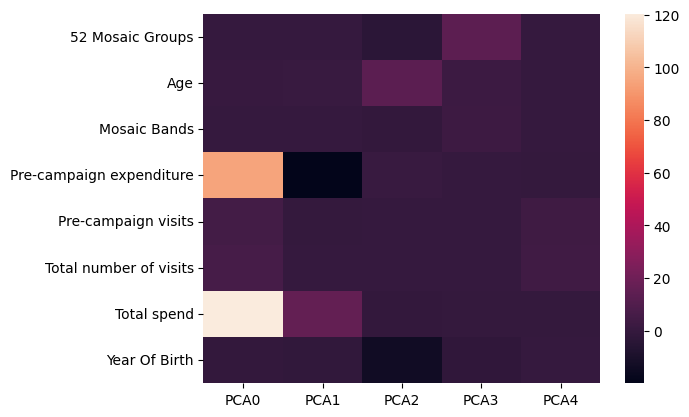

In [39]:
sns.heatmap(pca_loadings)

In [40]:
# use this new dimensions to train the model
X_pca_test = pca.transform(X_test)
X_pca_test = pd.DataFrame(X_pca_test, columns=list(pca.get_feature_names_out()))
clf = SVC(random_state=43)
ad.cross_validation_avg_scores(X_pca, y_train, clf)
y_pred = clf.predict(X_pca_test)
print(classification_report(y_test, y_pred))

Mean Accuracy is 90.98 +/- 1.02
Mean Precision is 93.27 +/- 1.16
Mean Recall is 85.95 +/- 1.39
Mean F-score is 88.56 +/- 1.34
               precision    recall  f1-score   support

Non-responder       0.90      1.00      0.95       323
    Responder       0.99      0.77      0.87       157

     accuracy                           0.92       480
    macro avg       0.95      0.88      0.91       480
 weighted avg       0.93      0.92      0.92       480



## What if we apply scaling?

In [41]:
# scale regular attributes since ranges are quite different
X_scaled = StandardScaler().fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [42]:
svd = TruncatedSVD(n_components=8, algorithm='randomized', random_state=43)
X_svd = svd.fit_transform(X_scaled)
# store the components into a dataframe
X_svd = pd.DataFrame(X_svd, columns=list(svd.get_feature_names_out()))
X_svd.head()

,truncatedsvd0,truncatedsvd1,truncatedsvd2,truncatedsvd3,truncatedsvd4,truncatedsvd5,truncatedsvd6,truncatedsvd7
0,-1.094056,-3.192452,-0.364795,-0.040938,-0.029386,0.010510,0.036313,-2.591242e-15
1,-1.170754,-1.101383,-2.232954,0.113244,-0.002123,-0.007136,-0.024831,-3.071272e-15
2,-0.492965,-1.387995,-2.043773,-0.377324,-0.035077,0.041332,-0.156232,-2.849227e-15
3,-0.815489,-2.260362,-1.162638,-0.087420,-0.044392,0.025461,0.177578,-2.627183e-15
4,-0.583262,-1.416180,-1.864642,-0.178550,-0.046533,0.030589,-0.007683,-3.107213e-15


In [43]:
pca = PCA(n_components=8, svd_solver='randomized', random_state=43)
X_pca = pca.fit_transform(X_scaled)
# store the components into a dataframe
X_pca = pd.DataFrame(X_pca, columns=list(pca.get_feature_names_out()))
X_pca.head()

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7
0,-1.094056,-3.192452,-0.364795,-0.040938,-0.029386,0.010510,0.036313,-6.631670e-17
1,-1.170754,-1.101383,-2.232954,0.113244,-0.002123,-0.007136,-0.024831,2.525197e-16
2,-0.492965,-1.387995,-2.043773,-0.377324,-0.035077,0.041332,-0.156232,-1.214391e-16
3,-0.815489,-2.260362,-1.162638,-0.087420,-0.044392,0.025461,0.177578,3.312828e-18
4,-0.583262,-1.416180,-1.864642,-0.178550,-0.046533,0.030589,-0.007683,-5.340638e-18


In [44]:
print("======= SVD Results ========")
print([format("%.3f" % sing_val) for sing_val in svd.singular_values_])
print([format("%.3f" % expl_var) for expl_var in svd.explained_variance_ratio_])
print("======= PCA Results ========")
print([format("%.3f" % sing_val) for sing_val in pca.singular_values_])
print([format("%.3f" % expl_var) for expl_var in pca.explained_variance_ratio_])

======= SVD Results ========
['93.155', '72.691', '65.164', '27.217', '14.014', '4.915', '3.794', '0.000']
['0.452', '0.275', '0.221', '0.039', '0.010', '0.001', '0.001', '0.000']
======= PCA Results ========
['93.155', '72.691', '65.164', '27.217', '14.014', '4.915', '3.794', '0.000']
['0.452', '0.275', '0.221', '0.039', '0.010', '0.001', '0.001', '0.000']


## Visualising components by class label
- in many cases, the first 2 or 3 components (whether svd components or pca components) are the most useful as they capture most of the variance
  - to understand their predictiveness, we can plot them by class label column

Text(0.5, 1.0, "Fist 2 PCA components coloured by 'Response to campaign'")

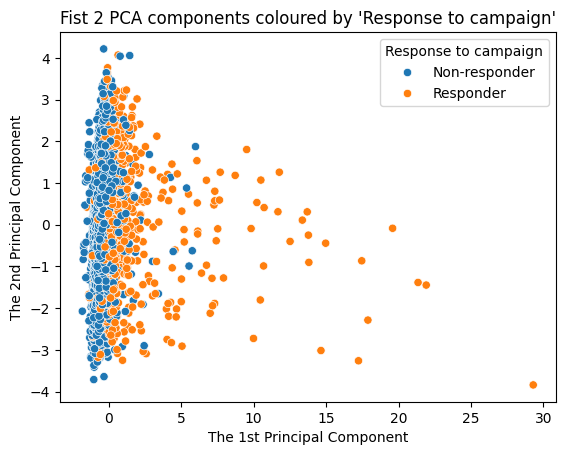

In [45]:
sns.scatterplot(x=X_pca.pca0, y=X_pca.pca1, hue=y)
plt.xlabel("The 1st Principal Component")
plt.ylabel("The 2nd Principal Component")
plt.title("Fist 2 PCA components coloured by 'Response to campaign'")

In [46]:
# EXERCISE: use a 3d scatter plot (e.g., px.scatter_3d function) to plot
# the first 3 SVD components coloured by class; interpret the results.

## Deciding on the number of optimal number of components
- we can use a scree plot:
  1. to plot the results (e.g., accuracy scores or f1 scores, depending on the business context) across various number of components and then use the elbow approach
  2. or, we can focus on the variance captured by each component
- this method is to a certain extent a subjective method and it is not useful when there is not an evident elbow in the plot
- there are other more objective methods, such as parallel analyis

- we will focus on SVD, but the same approach can be taken for PCA

Text(0, 0.5, 'Accuracy')

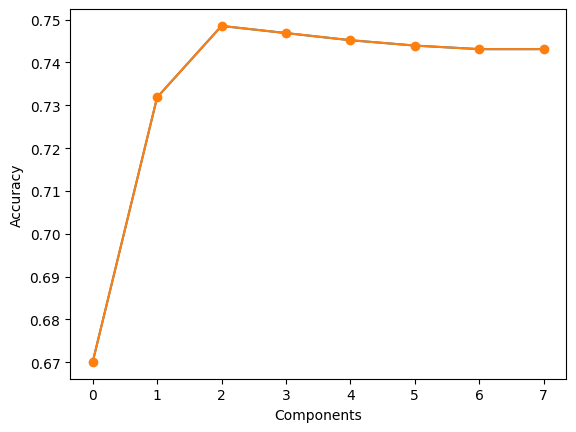

In [47]:
# 1.1. use scree plot to plot f1-scores across various number of components
accuracies = []
cumulative_variances = []
for n_comps in range(1, len(X.columns)+1):
  svd = TruncatedSVD(n_components=n_comps, random_state=43)
  X_svd = svd.fit_transform(X)
  f1 = cross_validate(clf, X_svd, y)
  accuracies.append(f1['test_score'].mean())
  cumulative_variances.append(np.sum(svd.explained_variance_ratio_))
ax = sns.lineplot(data=accuracies)
plt.plot(accuracies, marker='o')
plt.xlabel('Components')
plt.ylabel('Accuracy')

Text(0, 0.5, 'Cumulative Explained Variance')

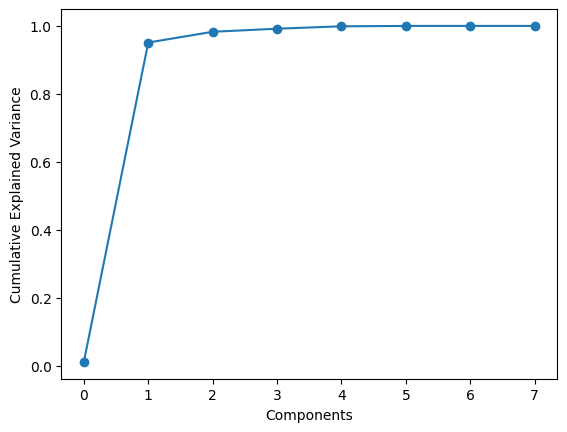

In [48]:
# 1.2. use scree plot to plot the explained variance captured by each component
plt.plot(cumulative_variances, marker='o')
plt.xlabel('Components')
plt.ylabel('Cumulative Explained Variance')

In [49]:
# EXERCISE: Use a grid search that optimises for f1 score to find out the optimal number of PCA components

## Reducing the risk of leakage
- as with many preparation techniques, data leakage can also occur in the case of SVD and PCA when used to build predictive models
- to reduce this, the SVD and PCA models should be generated on the training portion and then applied to test portion of the dataset
- typically, this should be done using pipelines with cross-validation


In [50]:
prep_pipeline = Pipeline(steps=[
    ('svd', TruncatedSVD(n_components=5, random_state=43))
])
ad.cross_val_pipeline(clf, prep_pipeline, X_train, y_train)

Mean Accuracy is 73.88 +/- 1.04
Mean Precision is 81.50 +/- 2.85
Mean Recall is 58.39 +/- 1.57
Mean F-score is 56.70 +/- 2.50


In [51]:
prep_pipeline = Pipeline(steps=[
    ('svd', PCA(n_components=5, random_state=43))
])
ad.cross_val_pipeline(clf, prep_pipeline, X_train, y_train)

Mean Accuracy is 90.88 +/- 1.77
Mean Precision is 93.40 +/- 1.48
Mean Recall is 85.69 +/- 2.74
Mean F-score is 88.35 +/- 2.48


# OPTIONAL
## Alternative Implementations

In [52]:
# 1.1. numpy implementation of svd function
# which returns 3 things, but we are only interested in the vector
# with singular values which are sorted in descending order
U, s, V = np.linalg.svd(X_scaled)
# print the singular values (with a prec.of 3 decimal digits)
print([format("%.3f" % singular_value) for singular_value in s])

['93.155', '72.691', '65.164', '27.217', '14.014', '4.915', '3.794', '0.000']


In [53]:
# 1.2. scipy implementation of svd function is very similar to numpy
# it returns 3 things, but we are only interested in the vector
# with singular values which are sorted in descending order
U1, s1, V1 = scipy.linalg.svd(X_scaled)
# print the singular values (with a prec.of 3 decimal digits)
print([format("%.3f" % singular_value) for singular_value in s1])

['93.155', '72.691', '65.164', '27.217', '14.014', '4.915', '3.794', '0.000']


In [54]:
# EXERCISE:apply similar approach as used for sklearn svd implementation to do
# SVD feature reduction and build a KNN model to compare to the results above.

# EXERCISE: check out documentation of mlxtend and implement both SVD and PCA;
# get the loadings and visualise them.

# EXERCISE: experiment with a different dataset

## Autoencoders
- autoencoders are neural networks that learn compressed representations of data using two main components:
  1. Encoder: Compresses input into latent-space representation
  2. Decoder: Reconstructs input from latent space
- We can use keras/TensorFlow
- Advantages:
  - Handles non-linear relationships
  - Can learn hierarchical representations
  - Works better with high-dimensional data
  - Flexible architecture customization

In [55]:
from tensorflow import keras
from tensorflow.keras import layers

In [56]:
input_dim = X_train.shape[1]  # number of original features
encoding_dim = 7  # number of new components

autoencoder = keras.Sequential([
    # encoder part
    layers.Input(shape=(input_dim,)),
    layers.Dense(16, activation='relu', kernel_regularizer='l2'),
    layers.Dense(10, activation='relu'),
    layers.Dense(encoding_dim, activation='relu'),

    # decoder part (asymmetry is better)
    layers.Dense(12, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(input_dim, activation='linear')  # activation could be sigmoid
])

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             170 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │              77 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 12)                  │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 8)                   │             136 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 831 (3.25 KB)

 Trainable params: 831 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 571872.8750 - val_loss: 536369.3125
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 527720.6875 - val_loss: 507111.5000
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 503296.8438 - val_loss: 491674.7188
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 489037.6562 - val_loss: 483499.5312
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 482757.3750 - val_loss: 479377.6562
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 478010.4062 - val_loss: 477333.5000
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 476998.4375 - val_loss: 474713.8750
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 474136.4062 - val_loss: 470327.6250
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 468933.4688 - val_loss: 463159.0625
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 460347.4688 - val_loss: 451424.5312
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 447654.6875

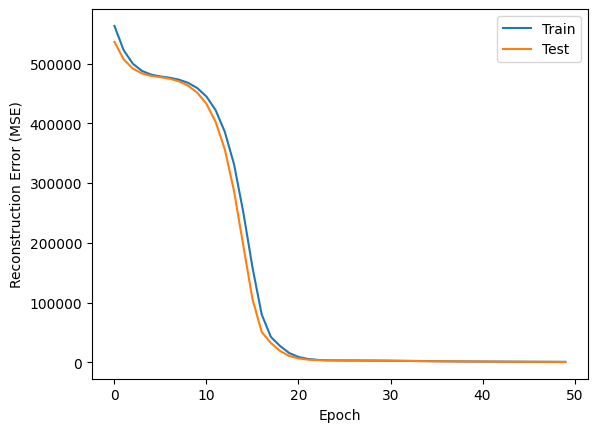

In [57]:
# train the autoencoder and validate on the test portion
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test)
)

# plot training history
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.ylabel('Reconstruction Error (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [58]:
# extract the encoder part
encoder = keras.Sequential([
    layers.InputLayer(input_shape=(input_dim,)),
    autoencoder.layers[0],
    autoencoder.layers[1],
    autoencoder.layers[2]
])

# use the encoder to reduce dimensions/number of features
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

print(f"Reduced dimension: {X_train_encoded.shape[1]}")  # 7 features

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Reduced dimension: 7


In [59]:
# build a new dataframe
X_train_encoded = pd.DataFrame(X_train_encoded,
          columns=[f'encoded_{i}' for i in range(X_train_encoded.shape[1])])
X_train_encoded.head()

,encoded_0,encoded_1,encoded_2,encoded_3,encoded_4,encoded_5,encoded_6
0,1251.477051,254.740402,894.447021,878.996643,645.399414,339.627533,0.0
1,1170.942993,290.786346,853.123535,900.544739,706.405029,349.125671,0.0
2,1223.194580,271.550598,874.837402,906.296265,686.316223,345.129272,0.0
3,1215.366821,271.333221,873.808350,894.337952,676.987305,343.135834,0.0
4,1244.973755,257.066711,892.139099,877.500916,646.583435,339.447784,0.0


In [60]:
# use this new dimensions to train
clf = SVC(random_state=43)
ad.cross_validation_avg_scores(X_train_encoded, y_train, clf)
y_pred = clf.predict(X_test_encoded)
print(classification_report(y_test, y_pred))

Mean Accuracy is 75.50 +/- 0.55
Mean Precision is 80.30 +/- 1.35
Mean Recall is 61.55 +/- 1.03
Mean F-score is 61.64 +/- 1.46
               precision    recall  f1-score   support

Non-responder       0.75      0.98      0.85       323
    Responder       0.89      0.32      0.47       157

     accuracy                           0.76       480
    macro avg       0.82      0.65      0.66       480
 weighted avg       0.80      0.76      0.72       480

